In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             roc_curve, precision_recall_curve, 
                             ConfusionMatrixDisplay)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

In [2]:
X_train = pd.read_csv(r'd:\Projects\credit-risk-network\data\processed\X_train.csv')
X_test = pd.read_csv(r'd:\Projects\credit-risk-network\data\processed\X_test.csv')
y_train = pd.read_csv(r'd:\Projects\credit-risk-network\data\processed\y_train.csv').squeeze()
y_test = pd.read_csv(r'd:\Projects\credit-risk-network\data\processed\y_test.csv').squeeze()

print("Data loaded successfully")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Data loaded successfully
X_train: (119999, 10)
X_test: (30000, 10)


In [3]:
# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
print("✓ Logistic Regression trained")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("✓ Random Forest trained")

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=14,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
print("✓ XGBoost trained")
print("\nAll models trained successfully")

✓ Logistic Regression trained
✓ Random Forest trained
✓ XGBoost trained

All models trained successfully


In [4]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb_model
}

results = {}

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'AUC-ROC': round(auc, 4),
        'Precision (Default)': round(report['1']['precision'], 4),
        'Recall (Default)': round(report['1']['recall'], 4),
        'F1 (Default)': round(report['1']['f1-score'], 4)
    }
    print(f"{name}: AUC = {auc:.4f}")

results_df = pd.DataFrame(results).T
print("\n=== MODEL COMPARISON ===")
print(results_df)

Logistic Regression: AUC = 0.8124
Random Forest: AUC = 0.8437
XGBoost: AUC = 0.8692

=== MODEL COMPARISON ===
                     AUC-ROC  Precision (Default)  Recall (Default)  \
Logistic Regression   0.8124               0.6450            0.0544   
Random Forest         0.8437               0.5404            0.1900   
XGBoost               0.8692               0.2162            0.7815   

                     F1 (Default)  
Logistic Regression        0.1003  
Random Forest              0.2812  
XGBoost                    0.3387  


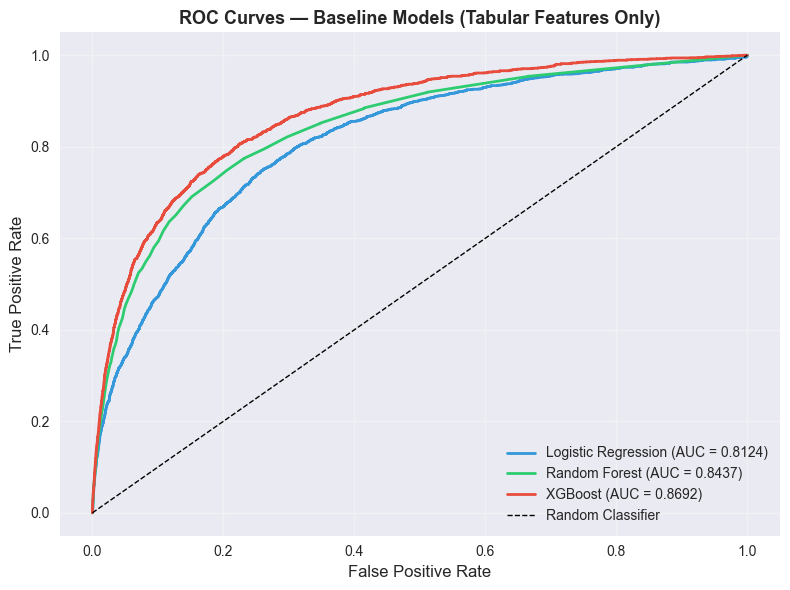

Plot saved.


In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, model), color in zip(models.items(), colors):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Baseline Models (Tabular Features Only)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'd:\Projects\credit-risk-network\outputs\plots\06_roc_curves_baseline.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [6]:
import pickle
import os

# Save results table
results_df.to_csv(r'd:\Projects\credit-risk-network\outputs\reports\baseline_model_results.csv')

# Save best model (XGBoost)
with open(r'd:\Projects\credit-risk-network\outputs\models\xgboost_baseline.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save all models for later comparison
with open(r'd:\Projects\credit-risk-network\outputs\models\all_baseline_models.pkl', 'wb') as f:
    pickle.dump(models, f)

print("=== BASELINE MODELS COMPLETE ===")
print("\nResults:")
print(results_df)
print("\nBest model: XGBoost")
print(f"Baseline AUC to beat: 0.8692")
print("\nNext step: Build borrower network → extract graph features → beat this score")

=== BASELINE MODELS COMPLETE ===

Results:
                     AUC-ROC  Precision (Default)  Recall (Default)  \
Logistic Regression   0.8124               0.6450            0.0544   
Random Forest         0.8437               0.5404            0.1900   
XGBoost               0.8692               0.2162            0.7815   

                     F1 (Default)  
Logistic Regression        0.1003  
Random Forest              0.2812  
XGBoost                    0.3387  

Best model: XGBoost
Baseline AUC to beat: 0.8692

Next step: Build borrower network → extract graph features → beat this score
